# Persiapan library




In [37]:
from google.colab import drive
import os
import pandas as pd
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import pathlib
from PIL import Image
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ReduceLROnPlateau


In [2]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

### Data Load

In [24]:
IMG_SIZE = (300, 300)
NUM_CLASSES = 5
BATCH_SIZE = 32

## Mengambil gambar

In [7]:
drive.mount('/content/drive')
dataset_path = '/content/drive/MyDrive/sampah'
print(os.listdir(dataset_path))

df_path = os.path.join(dataset_path, 'Sampah')
df_sampah = os.listdir(df_path)
print(df_sampah)


Mounted at /content/drive
['Sampah', 'Salinan Sampah', 'train', 'test', 'best_model1.keras']
['glass', 'cardboard', 'clothes', 'metal', 'paper', 'plastic', 'shoes', 'battery', 'trash', 'biological', 'Food', 'vegetables and fruits', 'Leaf', 'Pad and Diaper', 'Drug', 'tisu']


## mengcopy data traning dan test ke penyimpanan google colab

In [8]:


src = '/content/drive/MyDrive/sampah/train'
src1 = '/content/drive/MyDrive/sampah/test'
dst = '/content/sampah/train'
dst1 = '/content/sampah/test'

if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree(src, dst)
if os.path.exists(dst1):
    shutil.rmtree(dst1)

shutil.copytree(src1, dst1)

'/content/sampah/test'

## membagi data jadi organik, anorganik, kertas, residu dan B3

In [10]:
stats = []
for category in os.listdir(df_path):
    path = os.path.join(df_path, category)
    if os.path.isdir(path):
        count = len(os.listdir(path))
        stats.append({'Kategori': category, 'Jumlah Gambar': count})

df_stats = pd.DataFrame(stats)
sampah_mapping = {
    'Food': 'Organik',
    'biological': 'Organik',
    'Leaf': 'Organik',
    'vegetables and fruits': 'Organik',

    'clothes': 'Anorganik',
    'glass': 'Anorganik',
    'plastic': 'Anorganik',
    'shoes': 'Anorganik',
    'metal': 'Anorganik',

    'cardboard': 'Kertas',
    'paper': 'Kertas',

    'Drug': 'B3',
    'battery': 'B3',

    'tisu': 'Residu',
    'trash': 'Residu',
    'Pad and Diaper': 'Residu'
}

df_stats['trash'] = df_stats['Kategori'].map(sampah_mapping)

df = df_stats.groupby('trash').agg(
    Jumlah=('Jumlah Gambar', 'sum'),
    Jumlah_Jenis=('Kategori', 'nunique')
).reset_index()

df.columns = ['Kategori Trash', 'Jumlah', 'Jumlah Jenis']

df_sampah_stats = df.sort_values(by='Jumlah', ascending=False)

print(df_sampah_stats.to_string(index=False))
print("-"*40)
print(f"Total Seluruh Jenis Sampah Asli : {df_sampah_stats['Jumlah Jenis'].sum()}")
print(f"Total Seluruh Gambar Sampah     : {df_sampah_stats['Jumlah'].sum()}")

Kategori Trash  Jumlah  Jumlah Jenis
     Anorganik    7604             5
       Organik    3616             4
        Kertas    2747             2
            B3    2712             2
        Residu    1547             3
----------------------------------------
Total Seluruh Jenis Sampah Asli : 16
Total Seluruh Gambar Sampah     : 18226


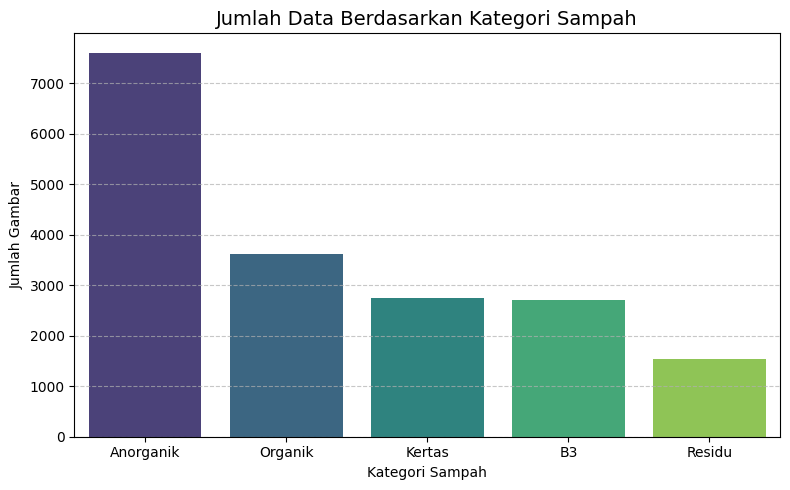

In [ ]:

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_sampah_stats,
    x='Kategori Trash',
    y='Jumlah',
    hue='Kategori Trash',
    palette='viridis',
    legend=False
)

plt.title('Jumlah Data Berdasarkan Kategori Sampah', fontsize=14)
plt.xlabel('Kategori Sampah')
plt.ylabel('Jumlah Gambar')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# import shutil
df.head()

# shutil.rmtree('/content/sampah/train/trash')
# shutil.rmtree('/content/sampah/test/trash')

,Kategori Trash,Jumlah,Jumlah Jenis
0,Anorganik,7604,5
1,B3,2712,2
2,Kertas,2747,2
3,Organik,3616,4
4,Residu,1547,3


## Membuat dataframe untuk di pisah gambarnya

In [11]:
data = []

for category in os.listdir(df_path):

    category_path = os.path.join(df_path, category)

    if os.path.isdir(category_path):

        label = sampah_mapping[category]

        for file in os.listdir(category_path):

            if file.lower().endswith(('.jpg', '.jpeg', '.png')):

                data.append({
                    'filepath': os.path.join(category_path, file),
                    'label': label
                })

df_images = pd.DataFrame(data)

print(df_images.head())
print(df_images['label'].value_counts())

                                            filepath      label
0  /content/drive/MyDrive/sampah/Sampah/glass/gla...  Anorganik
1  /content/drive/MyDrive/sampah/Sampah/glass/gla...  Anorganik
2  /content/drive/MyDrive/sampah/Sampah/glass/gla...  Anorganik
3  /content/drive/MyDrive/sampah/Sampah/glass/gla...  Anorganik
4  /content/drive/MyDrive/sampah/Sampah/glass/gla...  Anorganik
label
Anorganik    7604
Organik      3616
Kertas       2747
B3           2711
Residu       1547
Name: count, dtype: int64


# Pembagian data

In [12]:
X = df_images['filepath']
y = df_images['label']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=200,
    stratify=y
)

## Menyatukan datafraem

In [ ]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})
print(df_tr.shape)
print(df_te.shape)

(16402, 3)
(1823, 3)


In [ ]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing



set    labels   
test   Anorganik     760
       B3            271
       Kertas        275
       Organik       362
       Residu        155
train  Anorganik    6844
       B3           2440
       Kertas       2472
       Organik      3254
       Residu       1392
dtype: int64 


                                                    path     labels    set
17070  /content/drive/MyDrive/sampah/Sampah/tisu/n150...     Residu   test
69     /content/drive/MyDrive/sampah/Sampah/clothes/c...  Anorganik  train
6111   /content/drive/MyDrive/sampah/Sampah/glass/gla...  Anorganik  train
115    /content/drive/MyDrive/sampah/Sampah/Drug/2712...         B3  train
373    /content/drive/MyDrive/sampah/Sampah/paper/pap...     Kertas  train


## Membuat folder baru yang isinya data latih dan test di drive

In [ ]:

def copy_file(row):

    file_path = row.path

    # fallback jika path tidak ada
    if not os.path.exists(file_path):

        file_path = os.path.join(
            df_path,
            row.labels,
            row.image
        )

    # folder tujuan
    dest_dir = os.path.join(
        dataset_path,
        row.set,
        row.labels
    )

    os.makedirs(dest_dir, exist_ok=True)

    # tujuan file
    file_dest = os.path.join(
        dest_dir,
        os.path.basename(file_path)
    )

    # copy jika belum ada
    if not os.path.exists(file_dest):

        try:
            shutil.copy2(file_path, file_dest)

        except Exception as e:

            print(f'Gagal copy: {file_path}')
            print(e)

rows = list(df_all.itertuples(index=False))

with ThreadPoolExecutor(max_workers=8) as executor:

    list(
        tqdm(
            executor.map(copy_file, rows),
            total=len(rows)
        )
    )

100%|██████████| 18225/18225 [33:01<00:00,  9.20it/s]


In [ ]:

dataset_path= '/content/sampah'
for root, dirs, files in os.walk(dataset_path):

    for file in files:

        file_path = os.path.join(root, file)

        try:
            img = Image.open(file_path)
            img.verify()

        except:
            print("Hapus file rusak:", file_path)
            os.remove(file_path)

In [14]:
train_fix = '/content/sampah/train'
test_fix = '/content/sampah/test'


train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.1271
)

val_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.1271
)
train_data = train_datagen.flow_from_directory(
    train_fix,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = val_datagen.flow_from_directory(
    train_fix,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
)

test_data = test_datagen.flow_from_directory(
    test_fix,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 14320 images belonging to 5 classes.
Found 2082 images belonging to 5 classes.
Found 1823 images belonging to 5 classes.


In [15]:
classes = np.unique(train_data.classes)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_data.classes
)

print(weights)

[0.47933054 1.34460094 1.32715477 1.00809574 2.35526316]


In [16]:
def weighted_cce(weights):

    weights = tf.constant(
        weights,
        dtype=tf.float32
    )

    def loss(y_true, y_pred):

        ce = tf.keras.losses.categorical_crossentropy(
            y_true,
            y_pred
        )

        sample_weights = tf.reduce_sum(
            weights * y_true,
            axis=1
        )

        return ce * sample_weights

    return loss

In [ ]:

# ==================================================
# INPUT
# ==================================================

inputs = Input(shape=(300,300,3))

# ==================================================
# BASE MODEL
# ==================================================

base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_tensor=inputs
)

# freeze backbone awal
base_model.trainable = False

# ==================================================
# FEATURE EXTRACTION
# ==================================================

x = base_model.output

x = GlobalAveragePooling2D()(x)

# ==================================================
# CLASSIFIER HEAD
# ==================================================

x = Dense(
    256,
    activation='swish',
    kernel_regularizer=l2(0.001)
)(x)

x = BatchNormalization()(x)

x = Dropout(0.5)(x)

x = Dense(
    128,
    activation='swish',
    kernel_regularizer=l2(0.001)
)(x)

x = BatchNormalization()(x)

x = Dropout(0.4)(x)

x = Dense(
    64,
    activation='swish',
    kernel_regularizer=l2(0.001)
)(x)

x = BatchNormalization()(x)

x = Dropout(0.4)(x)

# ==================================================
# OUTPUT
# ==================================================

outputs = Dense(
    NUM_CLASSES,
    activation='softmax',
    dtype='float32'
)(x)

# ==================================================
# MODEL
# ==================================================

model = Model(inputs, outputs)

# ==================================================
# SUMMARY
# ==================================================

model.summary()

/tmp/ipykernel_5834/1311178715.py:26: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 150, 150,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 150, 150,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 150, 150,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 150, 150,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 150, 150,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 150, 150,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 150, 150,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 150, 150,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 150, 150,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 150, 150,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 150, 150,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 151, 151,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 75, 75,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 75, 75,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 75, 75,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 75, 75,    │      2,304 │ block_1_depthwis

 Total params: 2,629,189 (10.03 MB)

 Trainable params: 370,309 (1.41 MB)

 Non-trainable params: 2,258,880 (8.62 MB)

In [ ]:

weights = weights / np.min(weights)
print(weights)
loss_fn = weighted_cce(weights)
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5)
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy']
)

[1.         2.80516432 2.76876738 2.1031327  4.91365132]


In [21]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/sampah/best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=60,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 925ms/step - accuracy: 0.2362 - loss: 5.6566
Epoch 1: val_accuracy improved from None to 0.35062, saving model to /content/drive/MyDrive/best_model1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model1.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.2519 - loss: 5.4528 - val_accuracy: 0.3506 - val_loss: 3.6121 - learning_rate: 1.0000e-05
Epoch 2/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 844ms/step - accuracy: 0.3163 - loss: 4.8337
Epoch 2: val_accuracy improved from 0.35062 to 0.47935, saving model to /content/drive/MyDrive/best_model1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_model1.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 389s 867ms/step - accuracy: 0.3318 - loss: 4.6869 - val_accuracy: 0.4793 - val_loss: 3.0673 - learning_rate: 1.0000e-05
Epoch 3/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.3761 - loss: 4.3475
Epoch 3: val_accuracy improved from 0.47935 to 0.54707, saving mod

## Load Model awal

In [17]:
import keras
model = tf.keras.models.load_model("/content/drive/MyDrive/sampah/best_model1.keras", compile=False)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 150, 150,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 150, 150,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 150, 150,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 150, 150,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 150, 150,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 150, 150,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 150, 150,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 150, 150,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 150, 150,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 150, 150,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 150, 150,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 151, 151,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 75, 75,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 75, 75,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 75, 75,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 75, 75,    │      2,304 │ block_1_depthwis

 Total params: 2,629,189 (10.03 MB)

 Trainable params: 370,309 (1.41 MB)

 Non-trainable params: 2,258,880 (8.62 MB)

## melakukan Fine-tuning

In [22]:
# buka backbone
model.trainable = True

# freeze layer awal
for layer in model.layers[:-30]:
    layer.trainable = False

# compile ulang
loss_fn = weighted_cce(weights)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=loss_fn,
    metrics=['accuracy']
)


In [26]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=60,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 939ms/step - accuracy: 0.8357 - loss: 1.1313
Epoch 1: val_accuracy improved from None to 0.91835, saving model to /content/drive/MyDrive/sampah/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/sampah/best_model.keras
448/448 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.8378 - loss: 1.1372 - val_accuracy: 0.9183 - val_loss: 0.9871 - learning_rate: 1.0000e-05
Epoch 2/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.8369 - loss: 1.1366
Epoch 2: val_accuracy did not improve from 0.91835
448/448 ━━━━━━━━━━━━━━━━━━━━ 368s 821ms/step - accuracy: 0.8392 - loss: 1.1419 - val_accuracy: 0.9155 - val_loss: 0.9879 - learning_rate: 1.0000e-05
Epoch 3/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 803ms/step - accuracy: 0.8422 - loss: 1.1216
Epoch 3: val_accuracy did not improve from 0.91835
448/448 ━━━━━━━━━━━━━━━━━━━━ 370s 825ms/step - accuracy: 0.8415 - loss: 1.1235 - val_accuracy: 0.9159 - val_loss: 0.9845 - learning_rate: 1.0

In [27]:
predictions = model.predict(test_data)
pred_classes = np.argmax(predictions, axis=1)
true_classes = test_data.classes
class_names = list(test_data.class_indices.keys())
print(class_names)

57/57 ━━━━━━━━━━━━━━━━━━━━ 62s 667ms/step
['Anorganik', 'B3', 'Kertas', 'Organik', 'Residu']


In [28]:
report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_names
)

print(report)
print(class_names)

              precision    recall  f1-score   support

   Anorganik       0.97      0.93      0.95       760
          B3       0.92      0.90      0.91       271
      Kertas       0.87      0.92      0.89       275
     Organik       0.95      0.98      0.96       362
      Residu       0.83      0.88      0.86       155

    accuracy                           0.93      1823
   macro avg       0.91      0.92      0.91      1823
weighted avg       0.93      0.93      0.93      1823

['Anorganik', 'B3', 'Kertas', 'Organik', 'Residu']


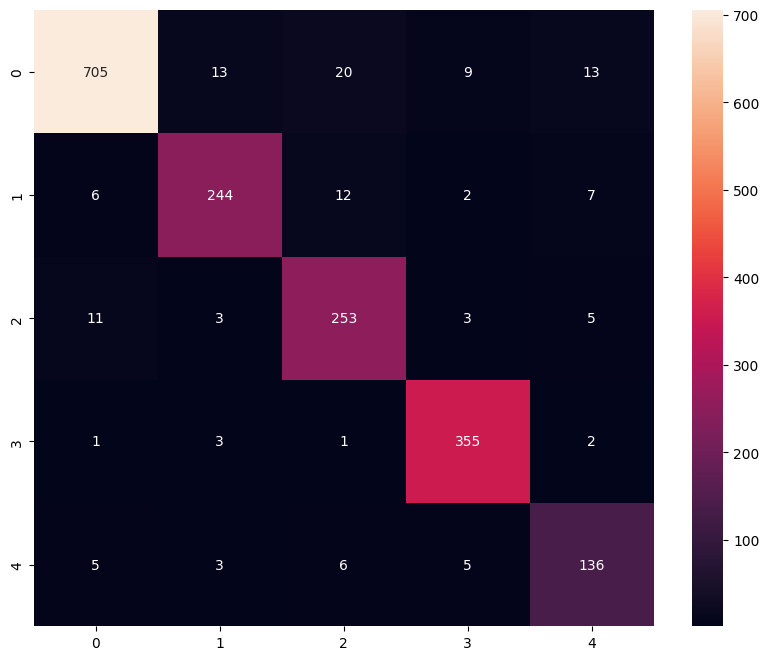

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## membuat kode Inference/ test menggunakan gambar asli/ gambar lain

1/1 ━━━━━━━━━━━━━━━━━━━━ 27s 27s/step
Prediksi: B3


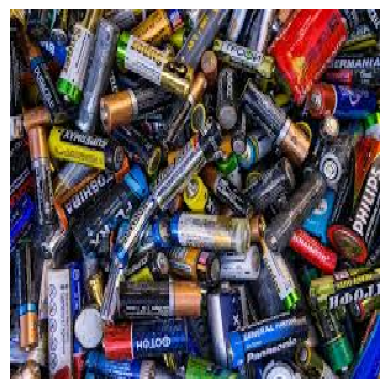

In [30]:
img_path = '/content/batre.jpeg'

img = image.load_img(
    img_path,
    target_size=(300,300)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Prediksi:", predicted_class)

plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 19s 19s/step
Prediksi: Anorganik


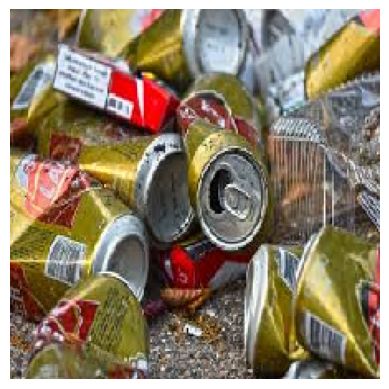

In [31]:
img_path = '/content/kaleng.jpeg'

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Prediksi:", predicted_class)

plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Prediksi: Kertas


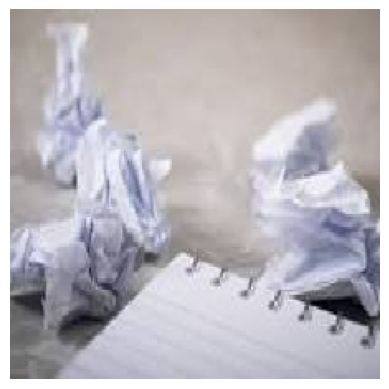

In [36]:
img_path = '/content/kertas1.jpeg'

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Prediksi:", predicted_class)

plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Prediksi: Organik


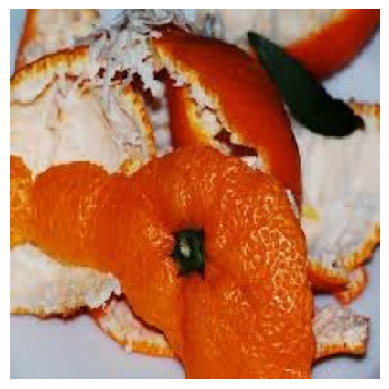

In [33]:
img_path = '/content/kulit_jeruk.jpeg'

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Prediksi:", predicted_class)

plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Prediksi: Residu


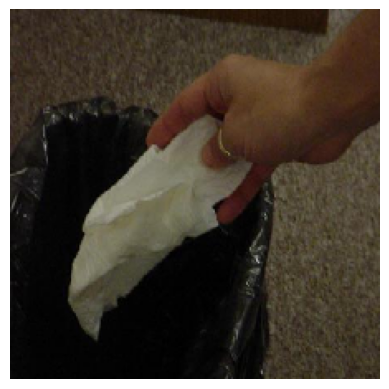

In [34]:
img_path = '/content/residu.jpg'

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Prediksi:", predicted_class)

plt.imshow(img)
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediksi: Organik


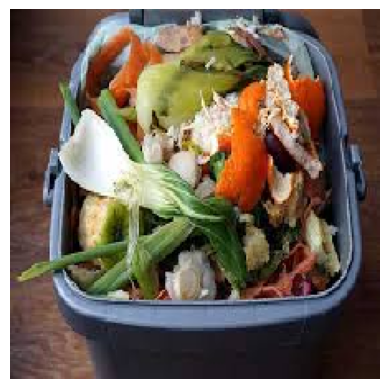

In [35]:
img_path = '/content/makanna.jpeg'

img = image.load_img(
    img_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)
img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Prediksi:", predicted_class)

plt.imshow(img)
plt.axis('off')
plt.show()